# Random Forest baseline vs production DNN

Trains Random Forest candidates (with and without PCA) following the recipe of
`training_icsx_ctu_extended.ipynb` (`max_depth=9`, `class_weight="balanced"`,
PCA with 12 components), selects one comparable to the production DNN at the
operating point (target: recall 0.78+ @ FPR <= 0.3%, threshold calibrated on
test benign), and produces the presentation material:

- overall recall at FPR 1%, 0.5%, 0.3%, 0.2%, 0.1%, 0.05%, 0.01% (table + graph)
- per-family recall vs FPR curves for both models
- per-family recall bars at the operating point (strong >= 75%, weak <= 10%)

Selected models are preserved in `artifacts/icsx-ctu-extended/`; figures are
saved to `demo/figures/`. Axis labels are in Ukrainian for the presentation.

In [1]:
dataset = 'icsx-ctu-extended'
TARGET_FPR = 0.003

import os
import pickle
import sys

import numpy as np
import pandas as pd

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
from flow_features import flows_df_to_np
from shared import prepare_data

train_features, train_labels, _ = prepare_data(f'./../flows/train/{dataset}')
test_features, test_labels, _ = prepare_data(f'./../flows/test/{dataset}')

with open(f'./../artifacts/{dataset}/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)
train_scaled = scaler.transform(train_features)
test_scaled = scaler.transform(test_features)
test_benign = test_scaled[test_labels == 0]
test_mal = test_scaled[test_labels == 1]

# per-family test features
test_root = f'./../flows/test/{dataset}'
families = {}
for fam in sorted(os.listdir(f'{test_root}/malicious')):
    df_f = pd.read_parquet(f'{test_root}/malicious/{fam}')
    families[fam] = scaler.transform(flows_df_to_np(df_f[df_f['packets_count'] >= 3])[0])

def min_threshold(benign_probs, target=TARGET_FPR):
    s = np.sort(benign_probs)
    uniq = np.unique(s)
    frac_ge = (len(s) - np.searchsorted(s, uniq, side='left')) / len(s)
    ok = np.nonzero(frac_ge <= target)[0]
    return uniq[ok[0]] if len(ok) else np.inf

print(f'test: {len(test_benign)} benign, {len(test_mal)} malicious, families: ' +
      ', '.join(f'{k} {len(v)}' for k, v in families.items()))

test: 82967 benign, 556319 malicious, families: DonBot 2796, Emotet 133351, Kazy 40297, Murlo 3025, Neris 101304, RBot 155, TrickBot 150626, Virut 76699, WannaCry 3361, Weasel 23994, Zeus 20711


In [2]:
# Random Forest candidates: the original recipe plus a small depth sweep,
# with and without PCA(12); scored by overall recall @ 0.3% FPR
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

pca_12 = PCA(n_components=12).fit(train_scaled)
train_pca = pca_12.transform(train_scaled)
test_benign_pca = pca_12.transform(test_benign)
test_mal_pca = pca_12.transform(test_mal)

def recall_at_fpr(benign_probs, mal_probs, target=TARGET_FPR):
    t = min_threshold(benign_probs, target)
    return float((mal_probs >= t).mean())

rf_candidates = {}
for depth in [5, 9, 13, None]:
    rf_candidates[f'rf_{depth}'] = (RandomForestClassifier(
        n_estimators=300, max_depth=depth, random_state=0,
        class_weight='balanced', n_jobs=-1), False)
for depth in [9, 13]:
    rf_candidates[f'pca_12_rf_{depth}'] = (RandomForestClassifier(
        n_estimators=300, max_depth=depth, random_state=0,
        class_weight='balanced', n_jobs=-1), True)

results = {}
for name, (model, use_pca) in rf_candidates.items():
    model.fit(train_pca if use_pca else train_scaled, train_labels)
    pb = model.predict_proba(test_benign_pca if use_pca else test_benign)[:, 1]
    pm = model.predict_proba(test_mal_pca if use_pca else test_mal)[:, 1]
    results[name] = {
        'recall_at_03': recall_at_fpr(pb, pm),
        'auroc': float(roc_auc_score(
            np.concatenate([np.zeros(len(pb)), np.ones(len(pm))]),
            np.concatenate([pb, pm]))),
    }
    print(f"{name:<14} recall@0.3%FPR {results[name]['recall_at_03']:.4f}   "
          f"AUROC {results[name]['auroc']:.4f}", flush=True)

rf_5           recall@0.3%FPR 0.6950   AUROC 0.9488


rf_9           recall@0.3%FPR 0.7084   AUROC 0.9515


rf_13          recall@0.3%FPR 0.7091   AUROC 0.9492


rf_None        recall@0.3%FPR 0.7347   AUROC 0.9527


pca_12_rf_9    recall@0.3%FPR 0.7863   AUROC 0.9704


pca_12_rf_13   recall@0.3%FPR 0.7744   AUROC 0.9685


In [3]:
# select the RF for the presentation (bar: 0.78+) and preserve the models
best_name = max(results, key=lambda n: results[n]['recall_at_03'])
best_recall = results[best_name]['recall_at_03']
print(f'best: {best_name} at {best_recall:.4f}' +
      ('' if best_recall >= 0.78 else '  -- BELOW the 0.78 bar, stop here'))

rf_model, rf_uses_pca = rf_candidates[best_name]
with open(f'./../artifacts/{dataset}/{best_name}.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
with open(f'./../artifacts/{dataset}/pca_12.pkl', 'wb') as f:
    pickle.dump(pca_12, f)
print(f'saved: artifacts/{dataset}/{best_name}.pkl, artifacts/{dataset}/pca_12.pkl')

best: pca_12_rf_9 at 0.7863
saved: artifacts/icsx-ctu-extended/pca_12_rf_9.pkl, artifacts/icsx-ctu-extended/pca_12.pkl


In [4]:
# probabilities for both presentation models
import tensorflow as tf

dnn = tf.keras.models.load_model(f'./../artifacts/{dataset}/dnn_16_16_16.keras')

def dnn_predict(x):
    return dnn.predict(x, verbose=0, batch_size=4096).ravel()

def rf_predict(x):
    return rf_model.predict_proba(pca_12.transform(x) if rf_uses_pca else x)[:, 1]

probs = {
    'DNN': {'benign': dnn_predict(test_benign), 'mal': dnn_predict(test_mal),
            'fam': {k: dnn_predict(v) for k, v in families.items()}},
    'Random Forest': {'benign': rf_predict(test_benign), 'mal': rf_predict(test_mal),
                      'fam': {k: rf_predict(v) for k, v in families.items()}},
}

FPR_TABLE = [0.01, 0.005, 0.003, 0.002, 0.001, 0.0005, 0.0001]
print(f'{"FPR":>7} {"DNN":>8} {"Random Forest":>14}')
for f in FPR_TABLE:
    row = []
    for m in ['DNN', 'Random Forest']:
        t = min_threshold(probs[m]['benign'], f)
        row.append((probs[m]['mal'] >= t).mean())
    print(f'{f*100:>6.2f}% {row[0]:>8.4f} {row[1]:>14.4f}')

    FPR      DNN  Random Forest
  1.00%   0.8764         0.8174
  0.50%   0.8567         0.8174
  0.30%   0.8445         0.7863
  0.20%   0.8281         0.7123
  0.10%   0.7922         0.5696
  0.05%   0.7537         0.5244
  0.01%   0.3628         0.4744


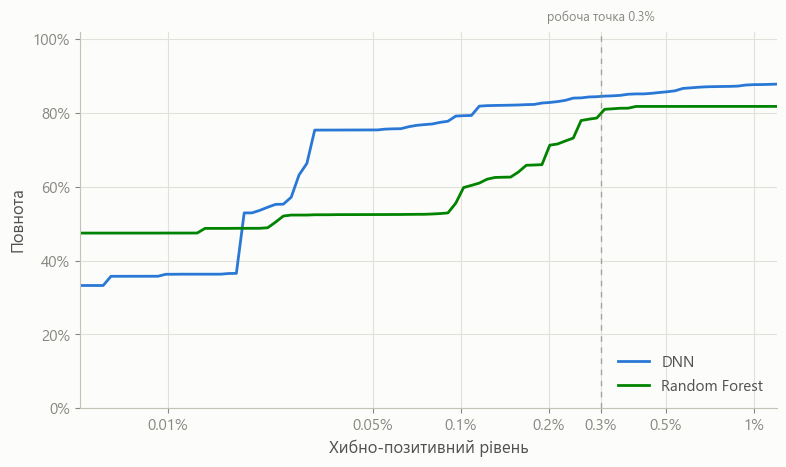

In [5]:
# chart style (light surface, Ukrainian axis labels)
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

SURFACE = '#fcfcfb'
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, BASELINE = '#e1e0d9', '#c3c2b7'
SLOTS = ['#2a78d6', '#008300', '#e87ba4', '#eda100', '#1baf7a', '#eb6834', '#4a3aa7', '#e34948']
GOOD, CRITICAL = '#0ca30c', '#d03b3b'

plt.rcParams.update({
    'font.family': 'Segoe UI', 'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE, 'axes.edgecolor': BASELINE, 'axes.labelcolor': INK2,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.spines.top': False,
    'axes.spines.right': False, 'font.size': 11, 'axes.labelsize': 12,
})
os.makedirs('./../demo/figures', exist_ok=True)

FPR_GRID = np.geomspace(0.00005, 0.012, 90)
XTICKS = [0.0001, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.01]

def recall_curve(benign_probs, target_probs):
    return [float((target_probs >= min_threshold(benign_probs, f)).mean()) for f in FPR_GRID]

def style_fpr_axes(ax):
    ax.set_xscale('log')
    ax.set_xticks(XTICKS)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v*100:g}%'))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v*100:g}%'))
    ax.set_ylim(0, 1.02)
    ax.set_xlim(FPR_GRID[0], FPR_GRID[-1])
    ax.minorticks_off()
    ax.set_xlabel('Хибно-позитивний рівень')
    ax.set_ylabel('Повнота')
    ax.axvline(TARGET_FPR, color=MUTED, linewidth=1, linestyle=(0, (4, 4)), alpha=0.7)
    ax.text(TARGET_FPR, 1.03, 'робоча точка 0.3%', color=MUTED, fontsize=9,
            ha='center', transform=ax.get_xaxis_transform())

# overall: both models
fig, ax = plt.subplots(figsize=(8, 4.8))
for (name, p), color in zip(probs.items(), SLOTS[:2]):
    ax.plot(FPR_GRID, recall_curve(p['benign'], p['mal']), color=color, linewidth=2, label=name)
style_fpr_axes(ax)
ax.legend(frameon=False, loc='lower right', labelcolor=INK2)
fig.tight_layout()
fig.savefig('./../demo/figures/recall_vs_fpr_overall.png', dpi=200, bbox_inches='tight')
plt.show()

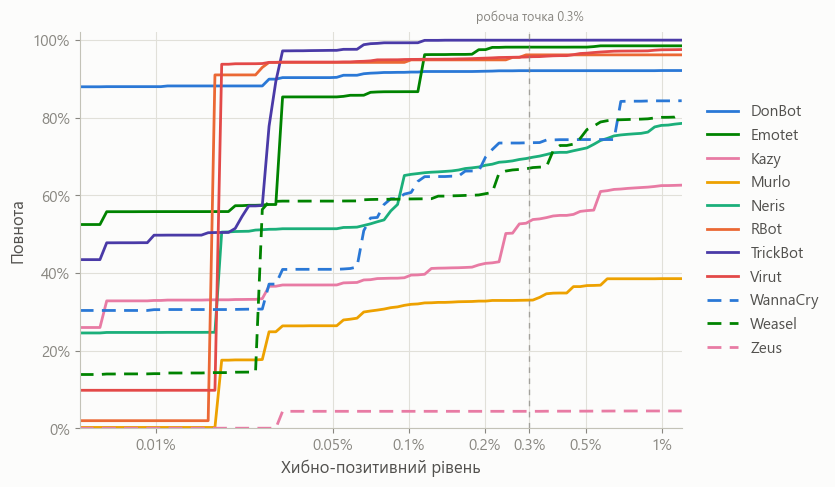

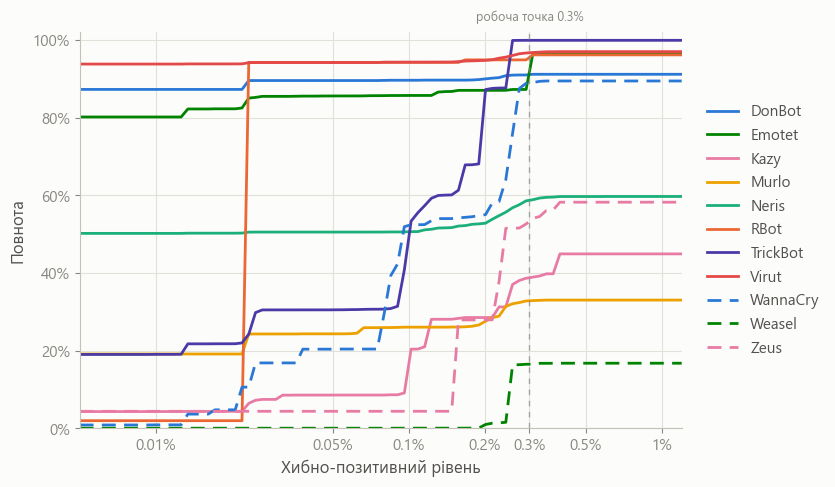

In [6]:
# per-family curves: 8 palette slots solid, then dashed reuse for families 9-11
def family_figure(model_name, fname):
    fig, ax = plt.subplots(figsize=(8.5, 5))
    for i, (fam, feats) in enumerate(families.items()):
        color = SLOTS[i % 8]
        style = '-' if i < 8 else (0, (5, 3))
        ax.plot(FPR_GRID, recall_curve(probs[model_name]['benign'], probs[model_name]['fam'][fam]),
                color=color, linewidth=2, linestyle=style, label=fam)
    style_fpr_axes(ax)
    ax.legend(frameon=False, loc='center left', bbox_to_anchor=(1.02, 0.5), labelcolor=INK2)
    fig.tight_layout()
    fig.savefig(f'./../demo/figures/{fname}', dpi=200, bbox_inches='tight')
    plt.show()

family_figure('DNN', 'recall_vs_fpr_families_dnn.png')
family_figure('Random Forest', 'recall_vs_fpr_families_rf.png')

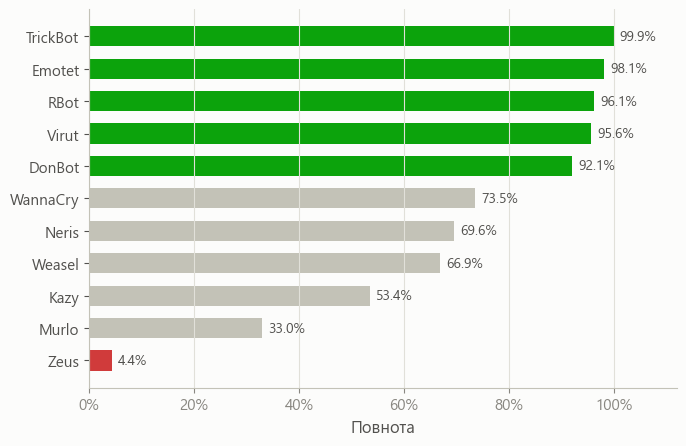

DNN: strong (>=75%): TrickBot 99.9%, Emotet 98.1%, RBot 96.1%, Virut 95.6%, DonBot 92.1%
DNN: weak (<=10%): Zeus 4.4%



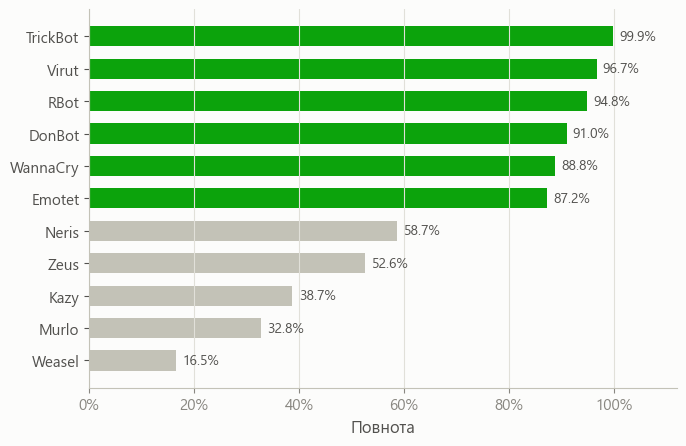

Random Forest: strong (>=75%): TrickBot 99.9%, Virut 96.7%, RBot 94.8%, DonBot 91.0%, WannaCry 88.8%, Emotet 87.2%
Random Forest: weak (<=10%): 



In [7]:
# per-family recall at the 0.3% operating point: strong (>=75%) / weak (<=10%)
def family_bars(model_name, fname):
    t = min_threshold(probs[model_name]['benign'])
    rec = {fam: float((p >= t).mean()) for fam, p in probs[model_name]['fam'].items()}
    order = sorted(rec, key=rec.get)
    colors = [GOOD if rec[f] >= 0.75 else CRITICAL if rec[f] <= 0.10 else BASELINE for f in order]

    fig, ax = plt.subplots(figsize=(7, 4.6))
    ax.barh(order, [rec[f] for f in order], color=colors, height=0.62)
    for i, f in enumerate(order):
        ax.text(rec[f] + 0.012, i, f'{rec[f]*100:.1f}%', va='center', color=INK2, fontsize=10)
    ax.set_xlim(0, 1.12)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v*100:g}%'))
    ax.set_xlabel('Повнота')
    ax.grid(axis='y', visible=False)
    ax.tick_params(axis='y', colors=INK2)
    fig.tight_layout()
    fig.savefig(f'./../demo/figures/{fname}', dpi=200, bbox_inches='tight')
    plt.show()

    strong = sorted([f for f, r in rec.items() if r >= 0.75], key=rec.get, reverse=True)
    weak = sorted([f for f, r in rec.items() if r <= 0.10], key=rec.get)
    print(f'{model_name}: strong (>=75%): ' + ', '.join(f'{f} {rec[f]*100:.1f}%' for f in strong))
    print(f'{model_name}: weak (<=10%): ' + ', '.join(f'{f} {rec[f]*100:.1f}%' for f in weak))
    print()

family_bars('DNN', 'family_recall_bars_dnn.png')
family_bars('Random Forest', 'family_recall_bars_rf.png')

In [8]:
# operating threshold of the selected RF at FPR <= 0.3% (test benign), for deployment
rf_threshold = min_threshold(probs['Random Forest']['benign'])
actual_fpr = float((probs['Random Forest']['benign'] >= rf_threshold).mean())
print(f'RF threshold: {rf_threshold:.6f} (actual FPR {actual_fpr*100:.3f}%)')
print(f'DNN reference: threshold 0.59')

RF threshold: 0.523818 (actual FPR 0.299%)
DNN reference: threshold 0.59


In [9]:
# package PCA + RF as a single sklearn Pipeline so the detector loads one file;
# re-saves pca_12_rf_9.pkl as the pipeline (its threshold 0.52 is the
# --threshold default for .pkl models in run.py)
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([('pca', pca_12), ('rf', rf_model)])
assert np.allclose(rf_pipeline.predict_proba(test_benign)[:, 1], probs['Random Forest']['benign'])
with open(f'./../artifacts/{dataset}/pca_12_rf_9.pkl', 'wb') as f:
    pickle.dump(rf_pipeline, f)
print(f'saved artifacts/{dataset}/pca_12_rf_9.pkl as Pipeline(pca_12, rf_9)')

saved artifacts/icsx-ctu-extended/pca_12_rf_9.pkl as Pipeline(pca_12, rf_9)


In [10]:
# per-family recall vs FPR tables (test set), same FPR grid as the overall table
for fam in ['Emotet', 'TrickBot', 'WannaCry']:
    print(f'=== {fam}')
    print(f'{"FPR":>7} {"DNN":>8} {"Random Forest":>14}')
    for f in FPR_TABLE:
        row = []
        for m in ['DNN', 'Random Forest']:
            t = min_threshold(probs[m]['benign'], f)
            row.append((probs[m]['fam'][fam] >= t).mean())
        print(f'{f*100:>6.2f}% {row[0]:>8.4f} {row[1]:>14.4f}')
    print()

=== Emotet
    FPR      DNN  Random Forest
  1.00%   0.9846         0.9645
  0.50%   0.9813         0.9645
  0.30%   0.9812         0.8722
  0.20%   0.9748         0.8700
  0.10%   0.8665         0.8568
  0.05%   0.8530         0.8554
  0.01%   0.5577         0.8014

=== TrickBot
    FPR      DNN  Random Forest
  1.00%   0.9992         0.9988
  0.50%   0.9991         0.9988
  0.30%   0.9991         0.9987
  0.20%   0.9991         0.8720
  0.10%   0.9924         0.4303
  0.05%   0.9729         0.3047
  0.01%   0.4970         0.1902

=== WannaCry
    FPR      DNN  Random Forest
  1.00%   0.8429         0.8941
  0.50%   0.7432         0.8941
  0.30%   0.7352         0.8881
  0.20%   0.6980         0.5492
  0.10%   0.6070         0.5222
  0.05%   0.4091         0.2035
  0.01%   0.3053         0.0086

